In [9]:
from google.colab import files
uploaded = files.upload()

Saving urdu_tfidf.pkl to urdu_tfidf (1).pkl


In [19]:
import joblib

urdu_tfidf = joblib.load("urdu_tfidf.pkl")

print("Urdu TF-IDF loaded successfully!")
print("Available variables:")
print([x for x in globals().keys() if not x.startswith("_")])

Urdu TF-IDF loaded successfully!
Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'files', 'uploaded', 'pd', 'urdu_df', 'MultinomialNB', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'classification_report', 'confusion_matrix', 'plt', 'sns', 'nb_urdu', 'pickle', 'train_test_split', 'LabelEncoder', 'f', 'io', 'tfidf_bytes', 'joblib', 'urdu_tfidf']


In [10]:
from google.colab import files
uploaded = files.upload()

Saving final_urdu_dataset.csv to final_urdu_dataset (1).csv


In [12]:
import pandas as pd

urdu_df = pd.read_csv("final_urdu_dataset.csv")

print(urdu_df.head())
print(urdu_df.columns)

                                             comment sentiment  \
0  اللہ آپکو سلامت رکھے جزائے خیر عطا فرمائے اور ...  positive   
1                                  اللہ سب سے بڑا ہے  positive   
2  سید محسن رضا نقوی پر یقین کرنے کو دل کرتا ھے ک...  positive   
3          نیازی خان ہیرو ثابت ہوا جیسے بڑوں گی مرضی  positive   
4                          آپ کی عظمت کو سلام شاہ جی  positive   

                                              tokens  
0  ['اللہ', 'آپکو', 'سلامت', 'رکھے', 'جزائے', 'خی...  
1                  ['اللہ', 'سب', 'سے', 'بڑا', 'ہے']  
2  ['سید', 'محسن', 'رضا', 'نقوی', 'پر', 'یقین', '...  
3  ['نیازی', 'خان', 'ہیرو', 'ثابت', 'ہوا', 'جیسے'...  
4    ['آپ', 'کی', 'عظمت', 'کو', 'سلام', 'شاہ', 'جی']  
Index(['comment', 'sentiment', 'tokens'], dtype='object')


Training shape: (5676, 27852)
Testing shape : (1419, 27852)

========== URDU - NAIVE BAYES ==========
Accuracy : 0.8534178999295279
Precision: 0.8694498930831556
Recall   : 0.8534178999295279
F1 Score : 0.8489802837409588

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.97      0.88       805
    positive       0.95      0.70      0.80       614

    accuracy                           0.85      1419
   macro avg       0.88      0.84      0.84      1419
weighted avg       0.87      0.85      0.85      1419



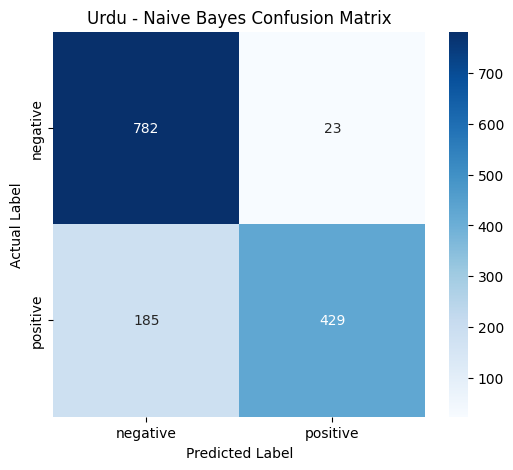

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# ==========================================
# URDU - NAIVE BAYES
# ==========================================

# Ensure 'comment' and 'sentiment' columns are clean before processing
# Fill NaN comments with empty strings to prevent errors in TF-IDF transformation
urdu_df['comment'] = urdu_df['comment'].fillna('')
# Drop rows where sentiment is NaN, as it's critical for labeling
urdu_df = urdu_df.dropna(subset=['sentiment'])

# Prepare features (X_urdu) and labels (y_urdu)
# Using the urdu_tfidf object loaded by joblib from cell mbewqlQ7yKQ_
X_urdu = urdu_tfidf.transform(urdu_df['comment'])

label_encoder = LabelEncoder()
y_urdu = label_encoder.fit_transform(urdu_df['sentiment'])

# Split Urdu TF-IDF data
X_urdu_train, X_urdu_test, y_urdu_train, y_urdu_test = train_test_split(
    X_urdu,
    y_urdu,
    test_size=0.20,
    random_state=42,
    stratify=y_urdu
)

print("Training shape:", X_urdu_train.shape)
print("Testing shape :", X_urdu_test.shape)

# Train Naive Bayes
nb_urdu = MultinomialNB()
nb_urdu.fit(X_urdu_train, y_urdu_train)

# Prediction
y_urdu_pred_nb = nb_urdu.predict(X_urdu_test)

# Results
print("\n========== URDU - NAIVE BAYES ==========")

accuracy = accuracy_score(y_urdu_test, y_urdu_pred_nb)
precision = precision_score(
    y_urdu_test, y_urdu_pred_nb, average="weighted"
)
recall = recall_score(
    y_urdu_test, y_urdu_pred_nb, average="weighted"
)
f1 = f1_score(
    y_urdu_test, y_urdu_pred_nb, average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_urdu_test,
    y_urdu_pred_nb,
    target_names=label_encoder.classes_
))

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_urdu_test, y_urdu_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Urdu - Naive Bayes Confusion Matrix")
plt.show()

In [23]:
from google.colab import files
uploaded = files.upload()

Saving roman_urdu_tfidf.pkl to roman_urdu_tfidf.pkl


In [24]:
from google.colab import files
uploaded = files.upload()

Saving final_roman_urdu_dataset.csv to final_roman_urdu_dataset.csv


In [25]:
import pandas as pd

urdu_df = pd.read_csv("final_roman_urdu_dataset.csv")

print(urdu_df.head())
print(urdu_df.columns)

                                             comment sentiment Unnamed: 2  \
0  sai kha ya her kisi kay bus ki bat nhi hai lak...  positive        NaN   
1                                      sahi but haan  positive        NaN   
2                                        kya but hai  positive        NaN   
3                                         wah je wah  positive        NaN   
4                               are wha kaya bat hai  positive        NaN   

                                              tokens  
0  ['sai', 'kha', 'ya', 'her', 'kisi', 'kay', 'bu...  
1                            ['sahi', 'but', 'haan']  
2                              ['kya', 'but', 'hai']  
3                               ['wah', 'je', 'wah']  
4               ['are', 'wha', 'kaya', 'bat', 'hai']  
Index(['comment', 'sentiment', 'Unnamed: 2', 'tokens'], dtype='object')


Training shape (Roman Urdu): (9039, 28345)
Testing shape (Roman Urdu) : (2260, 28345)

========== ROMAN URDU - NAIVE BAYES ==========
Accuracy : 0.79070796460177
Precision: 0.7905694740483656
Recall   : 0.79070796460177
F1 Score : 0.7905938247293526

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.77      0.77      1057
    positive       0.80      0.81      0.80      1203

    accuracy                           0.79      2260
   macro avg       0.79      0.79      0.79      2260
weighted avg       0.79      0.79      0.79      2260



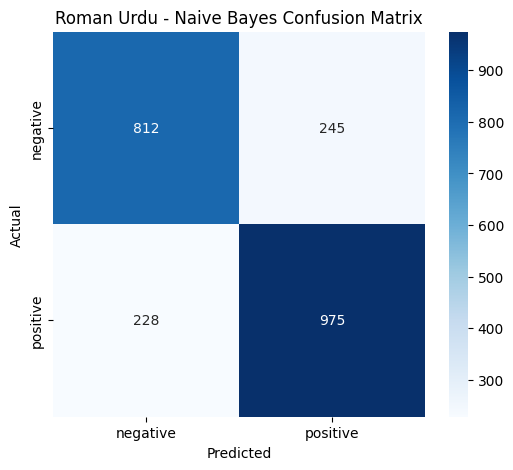

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.model_selection import train_test_split

# -------------------------------------------------
# 2. Roman Urdu
# -------------------------------------------------

# Load the Roman Urdu TF-IDF vectorizer
roman_urdu_tfidf = joblib.load("roman_urdu_tfidf.pkl")

# Ensure 'comment' and 'sentiment' columns are clean before processing
# Note: urdu_df was overwritten in cell PFW8qK_gviJm to contain Roman Urdu data
urdu_df['comment'] = urdu_df['comment'].fillna('')
urdu_df = urdu_df.dropna(subset=['sentiment'])

# Prepare features (X_roman) and labels (y_roman)
X_roman = roman_urdu_tfidf.transform(urdu_df['comment'])

label_encoder_roman = LabelEncoder()
y_roman = label_encoder_roman.fit_transform(urdu_df['sentiment'])

# Split Roman Urdu TF-IDF data
X_roman_train, X_roman_test, y_roman_train, y_roman_test = train_test_split(
    X_roman,
    y_roman,
    test_size=0.20,
    random_state=42,
    stratify=y_roman
)

print("Training shape (Roman Urdu):", X_roman_train.shape)
print("Testing shape (Roman Urdu) :", X_roman_test.shape)

nb_roman = MultinomialNB()
nb_roman.fit(X_roman_train, y_roman_train)

y_roman_pred_nb = nb_roman.predict(X_roman_test)

print("\n========== ROMAN URDU - NAIVE BAYES ==========")
print("Accuracy :", accuracy_score(y_roman_test, y_roman_pred_nb))
print("Precision:", precision_score(y_roman_test, y_roman_pred_nb, average="weighted"))
print("Recall   :", recall_score(y_roman_test, y_roman_pred_nb, average="weighted"))
print("F1 Score :", f1_score(y_roman_test, y_roman_pred_nb, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_roman_test, y_roman_pred_nb, target_names=label_encoder_roman.classes_))

cm_roman_nb = confusion_matrix(y_roman_test, y_roman_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_roman_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder_roman.classes_,
    yticklabels=label_encoder_roman.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Roman Urdu - Naive Bayes Confusion Matrix")
plt.show()

In [28]:
print([name for name in globals() if "nb" in name.lower()])

['MultinomialNB', 'nb_urdu', 'y_urdu_pred_nb', 'nb_roman', 'y_roman_pred_nb', 'cm_roman_nb']


In [29]:
import joblib

joblib.dump(nb_urdu, "urdu_naive_bayes.pkl")
joblib.dump(nb_roman, "roman_urdu_naive_bayes.pkl")

print("Both Naive Bayes models saved successfully!")

Both Naive Bayes models saved successfully!
